In [2]:
import matplotlib.pyplot as plt
#15
import pandas as pd
import numpy as np
df=pd.read_excel('catalog_products.xlsx')
df['log_price']=np.log(df['col_2'])
category_summary=df.groupby('col_7').agg(
    count=('col_7','count'),
    mean_price=('col_2','mean'),
    ful_q=('col_3','sum'),
    mean_l=('log_price','mean')
)
print(category_summary.head())

             count  mean_price    ful_q    mean_l
col_7                                            
Books         1994  494.009027   982076  5.879360
Clothing      1997  495.738608  1008454  5.892562
Electronics   2004  505.886228  1009669  5.933533
Home          1968  511.097561   995489  5.935257
Sports        2037  509.046637  1008988  5.939490


In [3]:
#16
i=df.groupby('col_7')['col_2'].idxmax()
most_expensive=df.loc[i,['col_1','col_2','col_7']]
print(most_expensive)

         col_1  col_2        col_7
1117    Sports    999        Books
1019      Home    999     Clothing
1478    Sports    999  Electronics
3101  Clothing    999         Home
2890    Sports    999       Sports


In [4]:
#17
df['total_value']=df['col_2']*df['col_3']
r=df.sort_values(by='total_value', ascending=False)
print(r.head(10))

            col_1  col_2  col_3        col_4  col_5  col_6        col_7  \
3833        Books    994    999        Books    261    621  Electronics   
4494       Sports    993    997        Books    649     69  Electronics   
9335     Clothing    994    992        Books    976      2     Clothing   
6431         Home    988    981        Books    738    494         Home   
3725  Electronics    997    971        Books    498    424     Clothing   
3389  Electronics    986    979        Books    167    232        Books   
3026  Electronics    997    968     Clothing    777    519     Clothing   
9202       Sports    966    996     Clothing    178    760         Home   
1380  Electronics    963    998  Electronics     94    331        Books   
3956     Clothing    982    975        Books     54    108        Books   

      col_8  col_9       col_10  ...       col_43  col_44 col_45       col_46  \
3833    967    623     Clothing  ...        Books     666    274        Books   
4494    981 

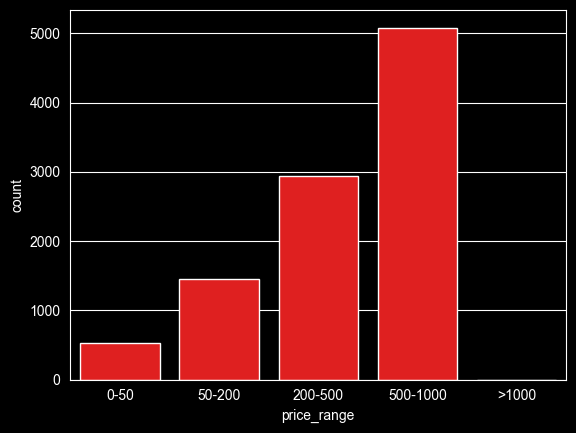

In [8]:
#18
import matplotlib.pyplot as plt
import seaborn as sns
b=[0,50,200,500,1000,float('inf')]
l=['0-50','50-200','200-500','500-1000','>1000']
df['price_range']=pd.cut(df['col_2'], bins=b,labels=l,include_lowest=True)
price_c=df['price_range'].value_counts().sort_index().reset_index()
price_c.columns=['price_range','count']
fig,ax=plt.subplots()
sns.barplot(x='price_range',y='count',data=price_c,ax=ax,color='red')
plt.show()

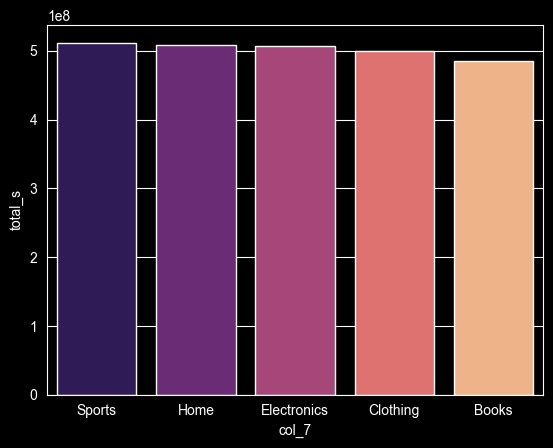

In [14]:
#19
df['stock_value']=df['col_2']*df['col_3']
cat_v=df.groupby('col_7').agg(
    total_s=('stock_value','sum')
).reset_index()

max_c=cat_v.sort_values(by='total_s',ascending=False)
fig,ax=plt.subplots()
sns.barplot(x='col_7',y='total_s',data=max_c,palette='magma')
plt.show()

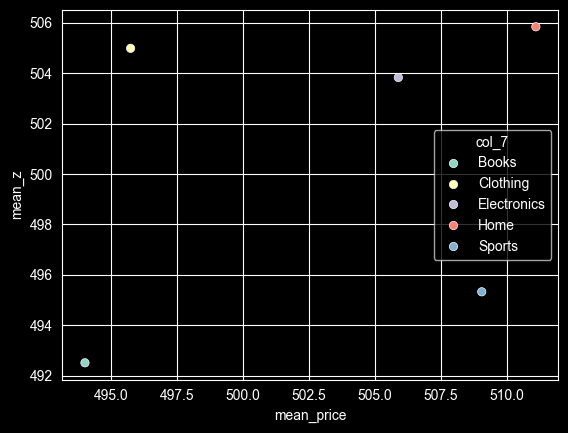

In [13]:
#20
cat=df.groupby('col_7').agg(
    mean_price=('col_2','mean'),
    mean_z=('col_3','mean'))

fig,ax=plt.subplots()
sns.scatterplot(x='mean_price',y='mean_z',data=cat,hue='col_7')
plt.show()